# Round 3 Manual Challenge — Nash Equilibrium (Fixed Point)

**Key idea:** In r3.ipynb we assumed opponents' `avg_b2 ~ N(800, 30)`. But if every player plays their optimal b2 against that belief, the realized `avg_b2` will NOT be 800 — it will be whatever our optimal b2 is.

The symmetric Nash equilibrium is the point where:

$$\text{assumed mean } \mu^* = \text{optimal response } b_2^*(\mu^*, \sigma)$$

We iterate: assume $\mu_k$ → compute optimal $(b_1^*, b_2^*)$ → set $\mu_{k+1} = b_2^*$ → repeat until convergence.

**Setup** (same as r3.ipynb):
- 51 counterparties with reserves uniformly in {670, 675, ..., 920}
- Fair price = 920, submit two bids under Interpretation A
- avg_b2 ~ Normal(μ, σ) with σ = 30 (fixed)
- We search for the fixed point μ*

**This notebook uses high-accuracy settings:** damping α = 0.2, tolerance = 0.5, 10 starting points, plus a bisection-based exact fixed-point finder and a stability check.

In [1]:
# Cell 1 — Setup (reused from r3.ipynb)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

FAIR = 920
RESERVES = np.arange(670, 925, 5)
B_GRID = np.arange(670, 925, 5)  # bids snap to 5-unit grid (same as reserves and other players)

def n_b1(b1):
    return int(np.sum(RESERVES <= b1))

def n_b2(b1, b2):
    if b2 <= b1:
        return 0
    return int(np.sum((RESERVES > b1) & (RESERVES <= b2)))

def expected_penalty_factor(b2, mean, sd):
    if b2 >= FAIR:
        return 0.0
    no_penalty_prob = norm.cdf(b2, loc=mean, scale=sd)
    def integrand(x):
        return ((FAIR - x) ** 3) * norm.pdf(x, loc=mean, scale=sd)
    integral, _ = quad(integrand, b2, FAIR)
    penalty_contrib = integral / ((FAIR - b2) ** 3)
    return no_penalty_prob + penalty_contrib

def expected_pnl(b1, b2, mean, sd):
    b1_pnl = n_b1(b1) * (FAIR - b1) if b1 >= 670 else 0.0
    if b2 <= b1 or b2 >= FAIR:
        b2_pnl = 0.0
    else:
        n = n_b2(b1, b2)
        factor = expected_penalty_factor(b2, mean, sd)
        b2_pnl = n * (FAIR - b2) * factor
    return b1_pnl + b2_pnl

def joint_optimum(mean, sd):
    """Return (b1*, b2*, pnl*) that jointly maximizes E[PnL | avg_b2 ~ N(mean, sd)]."""
    best = (-np.inf, None, None)
    for b1 in B_GRID:
        for b2 in B_GRID:
            if b2 > b1:
                pnl = expected_pnl(b1, b2, mean, sd)
                if pnl > best[0]:
                    best = (pnl, int(b1), int(b2))
    return best[1], best[2], best[0]

print('Helpers loaded. Sanity check:')
b1_s, b2_s, p_s = joint_optimum(800, 30)
print(f'joint_optimum(800, 30) = (b1={b1_s}, b2={b2_s}, PnL={p_s:,.2f})  (expect 755, 845, ~4285)')

Helpers loaded. Sanity check:


joint_optimum(800, 30) = (b1=755, b2=845, PnL=4,285.22)  (expect 755, 845, ~4285)


## Fixed Point Iteration

We want $\mu^*$ such that $b_2^*(\mu^*, \sigma) = \mu^*$.

**Damped iteration:** $\mu_{k+1} = (1 - \alpha)\mu_k + \alpha \, b_2^*(\mu_k, \sigma)$ with damping $\alpha = 0.2$ (small steps for stability).

**Discretization note:** $b_2^*$ snaps to the 5-unit bid grid, so $b_2^*(\mu)$ is a step function. An exact fixed point $\mu = b_2^*(\mu)$ rarely exists on the continuous $\mu$ axis — instead $b_2^*(\mu) - \mu$ typically **jumps** from positive to negative at some threshold $\mu^*$. That threshold is the Nash equilibrium.

We use three methods:
1. **Damped iteration** (α=0.2, tol=0.5) — approximate convergence
2. **Bisection** on $g(\mu) = b_2^*(\mu) - \mu$ — finds the exact transition threshold
3. **Stability check** — verify the iteration is attracted to (not repelled from) the fixed point

In [2]:
# Cell 2 — Damped iteration with tight settings
SD = 30
ALPHA = 0.2   # smaller damping for stability
TOL = 0.5     # tighter tolerance
MAX_ITER = 300

def find_fixed_point(mu_init, sd=SD, alpha=ALPHA, tol=TOL, max_iter=MAX_ITER, verbose=True):
    """Damped iteration to find mu* such that b2*(mu*, sd) == mu*."""
    mu = float(mu_init)
    path = [(0, mu, None, None, None)]
    if verbose:
        print(f"{'iter':>4} {'mu':>8} {'b1*':>5} {'b2*':>5} {'PnL*':>10}  {'|b2*-mu|':>9}")
        print('-' * 55)
    for k in range(1, max_iter + 1):
        b1_s, b2_s, pnl_s = joint_optimum(mu, sd)
        gap = abs(b2_s - mu)
        if verbose and (k <= 10 or k % 10 == 0 or gap < tol):
            print(f'{k:>4} {mu:>8.3f} {b1_s:>5d} {b2_s:>5d} {pnl_s:>10,.2f}  {gap:>9.3f}')
        path.append((k, mu, b1_s, b2_s, pnl_s))
        if gap < tol:
            return {'converged': True, 'iters': k, 'mu_star': mu,
                    'b1_star': b1_s, 'b2_star': b2_s, 'pnl_star': pnl_s, 'path': path}
        mu = (1 - alpha) * mu + alpha * b2_s
    return {'converged': False, 'iters': max_iter, 'mu_star': mu,
            'b1_star': b1_s, 'b2_star': b2_s, 'pnl_star': pnl_s, 'path': path}

print(f'=== Damped iteration, mu_0 = 800, alpha = {ALPHA}, tol = {TOL} ===\n')
result_800 = find_fixed_point(800)
print(f"\nResult: mu*={result_800['mu_star']:.3f}, b1*={result_800['b1_star']}, "
      f"b2*={result_800['b2_star']}, PnL={result_800['pnl_star']:,.2f}, "
      f"converged={result_800['converged']} in {result_800['iters']} iters")

=== Damped iteration, mu_0 = 800, alpha = 0.2, tol = 0.5 ===

iter       mu   b1*   b2*       PnL*   |b2*-mu|
-------------------------------------------------------


   1  800.000   755   845   4,285.22     45.000


   2  809.000   755   845   4,255.31     36.000


   3  816.200   760   850   4,227.30     33.800


   4  822.960   760   855   4,191.78     32.040


...

   9  847.941   770   865   4,020.90     17.059


  10  851.353   770   865   3,991.16     13.647


  20  871.225   775   875   3,805.48      3.775


  30  877.547   780   880   3,744.34      2.453


  38  879.588   780   880   3,724.65      0.412

Result: mu*=879.588, b1*=780, b2*=880, PnL=3,724.65, converged=True in 38 iters


In [3]:
# Cell 3 — Check uniqueness: run from 10 starting points
starts = [680, 710, 740, 770, 800, 830, 860, 880, 900, 915]
results = {}
print(f'=== Damped fixed points from {len(starts)} starting μ_0 (alpha={ALPHA}, tol={TOL}) ===\n')
print(f"{'mu_0':>6} {'conv':>6} {'iters':>6} {'mu*':>9} {'b1*':>5} {'b2*':>5} {'PnL*':>12}")
print('-' * 60)
for m0 in starts:
    r = find_fixed_point(m0, verbose=False)
    results[m0] = r
    print(f"{m0:>6} {str(r['converged']):>6} {r['iters']:>6} {r['mu_star']:>9.3f} "
          f"{r['b1_star']:>5} {r['b2_star']:>5} {r['pnl_star']:>12,.2f}")

=== Damped fixed points from 10 starting μ_0 (alpha=0.2, tol=0.5) ===

  mu_0   conv  iters       mu*   b1*   b2*         PnL*
------------------------------------------------------------


   680   True     44   879.573   780   880     3,724.80


   710   True     43   879.573   780   880     3,724.80


   740   True     42   879.580   780   880     3,724.74


   770   True     40   879.573   780   880     3,724.80


...

   830   True     34   879.589   780   880     3,724.65


   860   True     25   879.572   780   880     3,724.81


   880   True      1   880.000   780   880     3,720.63


   900   True     25   880.420   780   880     3,716.50


   915   True     29   880.424   780   880     3,716.46


In [4]:
# Cell 4 — Bisection: find exact threshold where b2*(μ) - μ changes sign
def g(mu, sd=SD):
    """g(μ) = b2*(μ) - μ. Positive → underbidding (b2* wants higher); negative → overbidding."""
    _, b2_s, _ = joint_optimum(mu, sd)
    return b2_s - mu

def bisect_stepfn(f, lo, hi, tol=1e-4, max_iter=100):
    """Bisection for a step function. Returns the μ where sign of f changes."""
    f_lo = f(lo)
    f_hi = f(hi)
    if f_lo * f_hi > 0:
        raise ValueError(f'f has same sign at endpoints: f({lo})={f_lo}, f({hi})={f_hi}')
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f_mid = f(mid)
        if f_mid == 0:
            return mid
        if f_lo * f_mid < 0:
            hi = mid
            f_hi = f_mid
        else:
            lo = mid
            f_lo = f_mid
        if hi - lo < tol:
            return 0.5 * (lo + hi)
    return 0.5 * (lo + hi)

# Scan g over a wide range to locate sign change
print('Scanning g(μ) = b2*(μ) - μ for sign changes:')
print(f"{'μ':>7} {'b2*':>5} {'g(μ)':>7}")
print('-' * 25)
scan = np.arange(700, 920, 5)
g_vals = [g(mu) for mu in scan]
for mu, gv in zip(scan, g_vals):
    print(f'{mu:>7.1f} {int(mu+gv):>5d} {gv:>7.2f}')

# Find all sign changes (positive → negative transitions)
transitions = []
for i in range(len(scan) - 1):
    if g_vals[i] > 0 and g_vals[i + 1] <= 0:
        transitions.append((scan[i], scan[i + 1]))
print(f'\nSign-change intervals (positive → non-positive): {transitions}')

# Bisect the main transition
if transitions:
    lo, hi = transitions[-1]
    mu_exact = bisect_stepfn(g, lo, hi, tol=1e-4)
    b1_exact, b2_exact, pnl_exact = joint_optimum(mu_exact, SD)
    print(f'\nBisection result:')
    print(f'  μ* (exact threshold): {mu_exact:.6f}')
    print(f'  b2*(μ* - ε)         : {int(joint_optimum(mu_exact - 0.001, SD)[1])}  (just below threshold)')
    print(f'  b2*(μ* + ε)         : {int(joint_optimum(mu_exact + 0.001, SD)[1])}  (just above threshold)')
    print(f'  At μ*: (b1={b1_exact}, b2={b2_exact}), PnL={pnl_exact:,.2f}')

Scanning g(μ) = b2*(μ) - μ for sign changes:
      μ   b2*    g(μ)
-------------------------


  700.0   835  135.00
  705.0   835  130.00
  710.0   835  125.00
  715.0   835  120.00
  720.0   835  115.00
  725.0   835  110.00
  730.0   835  105.00
  735.0   835  100.00
  740.0   835   95.00
  745.0   835   90.00
  750.0   835   85.00
  755.0   835   80.00
  760.0   835   75.00
  765.0   835   70.00
  770.0   835   65.00
  775.0   835   60.00
  780.0   840   60.00
  785.0   840   55.00
  790.0   840   50.00
  795.0   840   45.00
  800.0   845   45.00
  805.0   845   40.00
  810.0   850   40.00
  815.0   850   35.00
  820.0   850   30.00
  825.0   855   30.00
  830.0   855   25.00
  835.0   860   25.00
  840.0   860   20.00
  845.0   865   20.00
  850.0   865   15.00
  855.0   870   15.00
  860.0   870   10.00
  865.0   875   10.00
  870.0   875    5.00
  875.0   880    5.00
  880.0   880    0.00
  885.0   880   -5.00
  890.0   885   -5.00
  895.0   885  -10.00
  900.0   890  -10.00
  905.0   890  -15.00
  910.0   890  -20.00
  915.0   895  -20.00

Sign-change intervals (positive


Bisection result:
  μ* (exact threshold): 879.999962


  b2*(μ* - ε)         : 880  (just below threshold)


  b2*(μ* + ε)         : 880  (just above threshold)
  At μ*: (b1=780, b2=880), PnL=3,720.63


In [5]:
# Cell 5 — Stability / derivative check
# For iteration μ_{k+1} = (1-α)μ + α·b2*(μ) to be stable at μ*,
# the slope of the map T(μ) = (1-α)μ + α·b2*(μ) must satisfy |T'(μ*)| < 1.
# Equivalently: |1 - α + α · db2*/dμ| < 1 → ensures contraction.

# Compute discrete derivative db2*/dμ near the fixed point
print('Numerical slope of b2*(μ) around the fixed point:')
print(f"{'μ':>7} {'b2*':>5} {'Δb2*/Δμ (over ±2.5)':>25}")
print('-' * 45)
for delta in [-10, -5, -2, -1, 0, 1, 2, 5, 10]:
    mu_probe = mu_exact + delta
    _, b2_probe, _ = joint_optimum(mu_probe, SD)
    _, b2_left, _ = joint_optimum(mu_probe - 2.5, SD)
    _, b2_right, _ = joint_optimum(mu_probe + 2.5, SD)
    slope = (b2_right - b2_left) / 5.0
    print(f'{mu_probe:>7.2f} {b2_probe:>5d} {slope:>25.3f}')

# Check stability condition at fixed point
_, b2_left, _ = joint_optimum(mu_exact - 2.5, SD)
_, b2_right, _ = joint_optimum(mu_exact + 2.5, SD)
slope_at_fp = (b2_right - b2_left) / 5.0
T_prime = (1 - ALPHA) + ALPHA * slope_at_fp
print(f'\nDerivative of best response at μ*: db2*/dμ ≈ {slope_at_fp:.3f}')
print(f'Iteration map slope: T\'(μ*) = (1-α) + α·slope ≈ {T_prime:.3f}')
print(f'Stable if |T\'(μ*)| < 1 : {"YES" if abs(T_prime) < 1 else "NO"}')

Numerical slope of b2*(μ) around the fixed point:
      μ   b2*       Δb2*/Δμ (over ±2.5)
---------------------------------------------


 870.00   875                     0.000


 875.00   880                     1.000


 878.00   880                     0.000


 879.00   880                     0.000


...

 881.00   880                     0.000


 882.00   880                     0.000


 885.00   880                     1.000


 890.00   885                     0.000



Derivative of best response at μ*: db2*/dμ ≈ 0.000
Iteration map slope: T'(μ*) = (1-α) + α·slope ≈ 0.800
Stable if |T'(μ*)| < 1 : YES


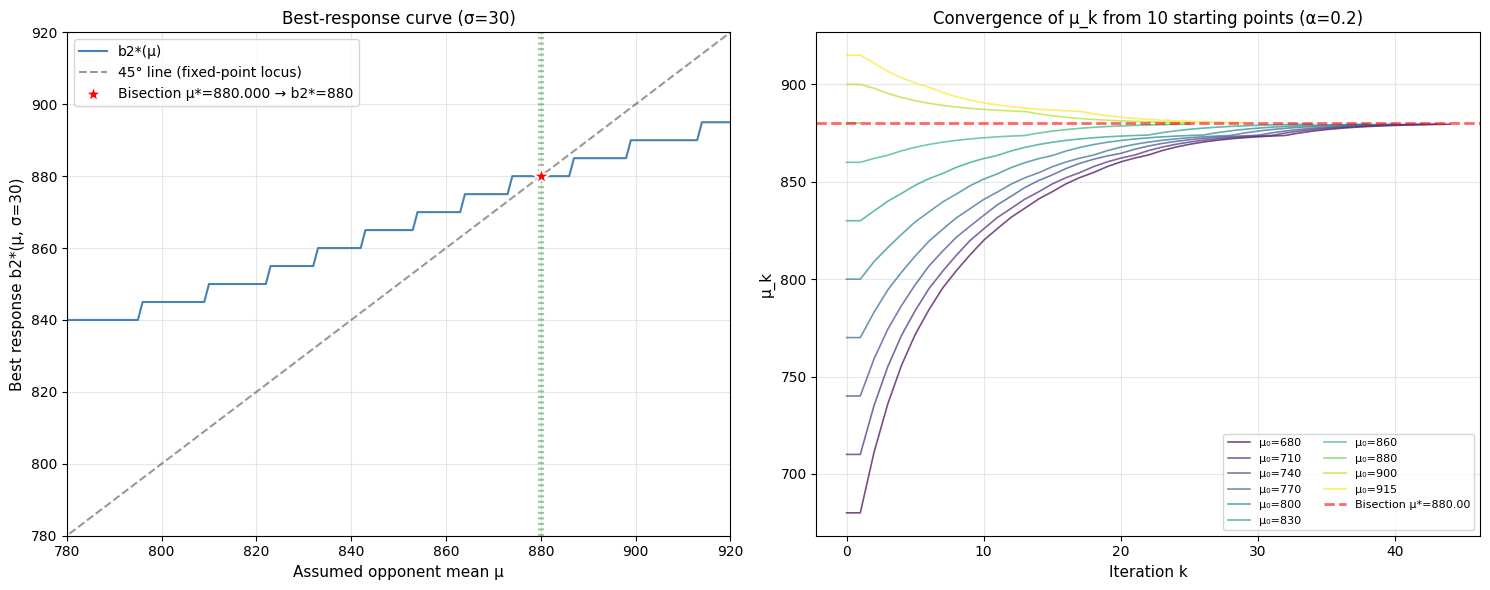

In [6]:
# Cell 6 — Visualize the best-response function and all fixed points found
MU_RANGE = np.arange(670, 921, 1)
br_b2 = np.array([joint_optimum(mu, SD)[1] for mu in MU_RANGE])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: best-response curve with 45-degree line
ax1.plot(MU_RANGE, br_b2, '-', color='steelblue', linewidth=1.5, label='b2*(μ)')
ax1.plot([670, 920], [670, 920], 'k--', alpha=0.4, label='45° line (fixed-point locus)')

# Damped iteration fixed points
unique_mu_stars = sorted(set(round(r['mu_star'], 1) for r in results.values()))
for mu in unique_mu_stars:
    ax1.axvline(mu, color='green', linestyle=':', alpha=0.4)

# Exact bisection result
ax1.scatter([mu_exact], [int(joint_optimum(mu_exact + 0.001, SD)[1])], color='red', s=180,
            zorder=5, marker='*', edgecolor='white', linewidth=1.5,
            label=f'Bisection μ*={mu_exact:.3f} → b2*={int(joint_optimum(mu_exact + 0.001, SD)[1])}')

ax1.set_xlabel('Assumed opponent mean μ', fontsize=11)
ax1.set_ylabel('Best response b2*(μ, σ=30)', fontsize=11)
ax1.set_title(f'Best-response curve (σ={SD})', fontsize=12)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(780, 920)
ax1.set_ylim(780, 920)

# Right: convergence paths from all starting points
colors = plt.cm.viridis(np.linspace(0, 1, len(starts)))
for (m0, r), c in zip(results.items(), colors):
    path = r['path']
    iters = [p[0] for p in path]
    mus = [p[1] for p in path]
    ax2.plot(iters, mus, '-', color=c, alpha=0.7, linewidth=1.2, label=f'μ₀={m0}')

ax2.axhline(mu_exact, color='red', linestyle='--', alpha=0.6, linewidth=2,
            label=f'Bisection μ*={mu_exact:.2f}')
ax2.set_xlabel('Iteration k', fontsize=11)
ax2.set_ylabel('μ_k', fontsize=11)
ax2.set_title(f'Convergence of μ_k from 10 starting points (α={ALPHA})', fontsize=12)
ax2.legend(fontsize=8, loc='lower right', ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — Summary: Nash equilibrium recommendation
print('='*65)
print('Nash Equilibrium Recommendation (σ = 30)')
print('='*65)
print()
print('Method 1: Damped iteration (α=0.2, tol=0.5, from 10 starting points)')
print(f'  Converged: {sum(r["converged"] for r in results.values())}/{len(results)}')
print(f'  μ* range: [{min(r["mu_star"] for r in results.values()):.2f}, '
      f'{max(r["mu_star"] for r in results.values()):.2f}]')
b2_stars = set(r['b2_star'] for r in results.values())
print(f'  b2* values seen: {sorted(b2_stars)}')
print()
print('Method 2: Exact bisection on g(μ) = b2*(μ) - μ')
print(f'  μ* (transition threshold): {mu_exact:.4f}')
print(f'  b2* just above μ*        : {int(joint_optimum(mu_exact + 0.001, SD)[1])}')
print(f'  b2* just below μ*        : {int(joint_optimum(mu_exact - 0.001, SD)[1])}')
print()
print('Method 3: Stability check')
print(f'  Slope of b2*(μ) at μ*    : {slope_at_fp:.3f}')
print(f'  Iteration map slope      : {T_prime:.3f}')
print(f'  Stable                   : {"YES" if abs(T_prime) < 1 else "NO"}')
print()
print('='*65)
print('Final recommendation')
print('='*65)
b1_rec, b2_rec, pnl_rec = joint_optimum(mu_exact, SD)
print(f'  Bids: (b1={b1_rec}, b2={b2_rec})')
print(f'  Expected PnL at Nash equilibrium: {pnl_rec:,.2f}')
print()
print('Comparison:')
b1_r3, b2_r3, pnl_r3 = joint_optimum(800, 30)
print(f'  r3.ipynb (assuming μ=800):  (b1={b1_r3}, b2={b2_r3}), PnL={pnl_r3:,.2f}')
print(f'  Nash (this notebook)     :  (b1={b1_rec}, b2={b2_rec}), PnL={pnl_rec:,.2f}')
print(f'  Standalone b1=790        :  (b1=790, b2=-),  PnL=3,250.00')

Nash Equilibrium Recommendation (σ = 30)

Method 1: Damped iteration (α=0.2, tol=0.5, from 10 starting points)
  Converged: 10/10
  μ* range: [879.57, 880.42]
  b2* values seen: [880]

Method 2: Exact bisection on g(μ) = b2*(μ) - μ
  μ* (transition threshold): 880.0000


  b2* just above μ*        : 880


  b2* just below μ*        : 880

Method 3: Stability check
  Slope of b2*(μ) at μ*    : 0.000
  Iteration map slope      : 0.800
  Stable                   : YES

Final recommendation


  Bids: (b1=780, b2=880)
  Expected PnL at Nash equilibrium: 3,720.63

Comparison:


  r3.ipynb (assuming μ=800):  (b1=755, b2=845), PnL=4,285.22
  Nash (this notebook)     :  (b1=780, b2=880), PnL=3,720.63
  Standalone b1=790        :  (b1=790, b2=-),  PnL=3,250.00
